In [1]:
## Heart Disease

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [3]:
import pandas as pd


In [4]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)

In [5]:

print("HEAD")
print(df.head())

HEAD
  patient_id  slope_of_peak_exercise_st_segment               thal  \
0     0z64un                                  1             normal   
1     ryoo3j                                  2             normal   
2     yt1s1x                                  1             normal   
3     l2xjde                                  1  reversible_defect   
4     oyt4ek                                  3  reversible_defect   

   resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                     128                2                  0   
1                     110                3                  0   
2                     125                4                  3   
3                     152                4                  0   
4                     178                1                  0   

   fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
0                                     0                    2   
1                                     0                

In [6]:
print("TAIL ")

print(df.tail())

TAIL 
    patient_id  slope_of_peak_exercise_st_segment               thal  \
175     5qfar3                                  2  reversible_defect   
176     2s2b1f                                  2             normal   
177     nsd00i                                  2  reversible_defect   
178     0xw93k                                  1             normal   
179     2nx10r                                  1             normal   

     resting_blood_pressure  chest_pain_type  num_major_vessels  \
175                     125                4                  2   
176                     180                4                  0   
177                     125                3                  0   
178                     124                3                  2   
179                     160                3                  1   

     fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
175                                     1                    0   
176                       

In [7]:
#!pip install imbalanced-learn


In [8]:
# Heart Disease Prediction Using Logistic Regression with SMOTE, Scaling, Confusion Matrix, and ROC Curve

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import SMOTE


In [10]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)
df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [11]:
# Encode all string/object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])


In [12]:
# 🔹 Define Target and Remove Original Column to Prevent Target Leakage
df['Target'] = df['exercise_induced_angina']   
df = df.drop(columns=['exercise_induced_angina'])  

In [13]:
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [15]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [16]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability for positive class


In [18]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

In [19]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 75.00%


In [20]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.58      0.64      0.61        11

    accuracy                           0.75        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.76      0.75      0.75        36



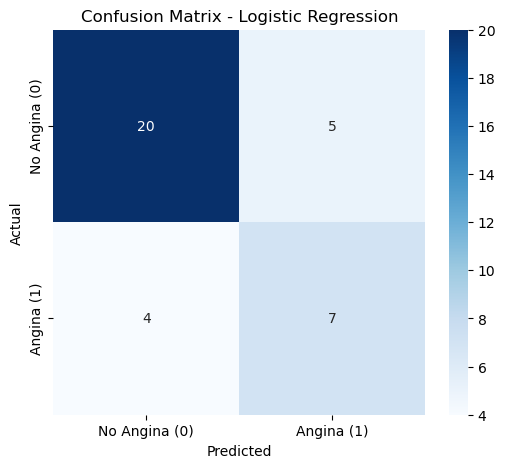

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["No Angina (0)", "Angina (1)"],
            yticklabels=["No Angina (0)", "Angina (1)"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


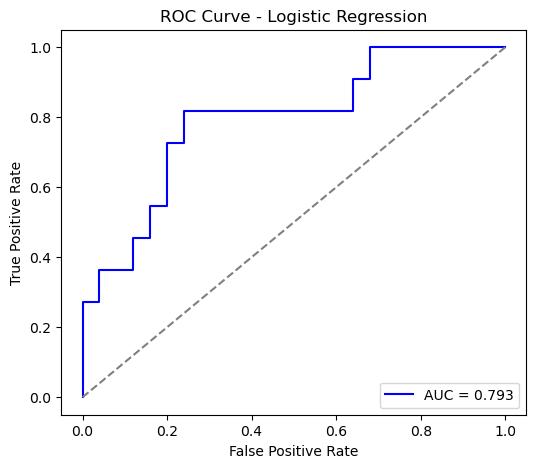

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='blue')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()


C:\Users\rainc\AppData\Local\Temp\ipykernel_19752\581385656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=feature_importance, palette="viridis")


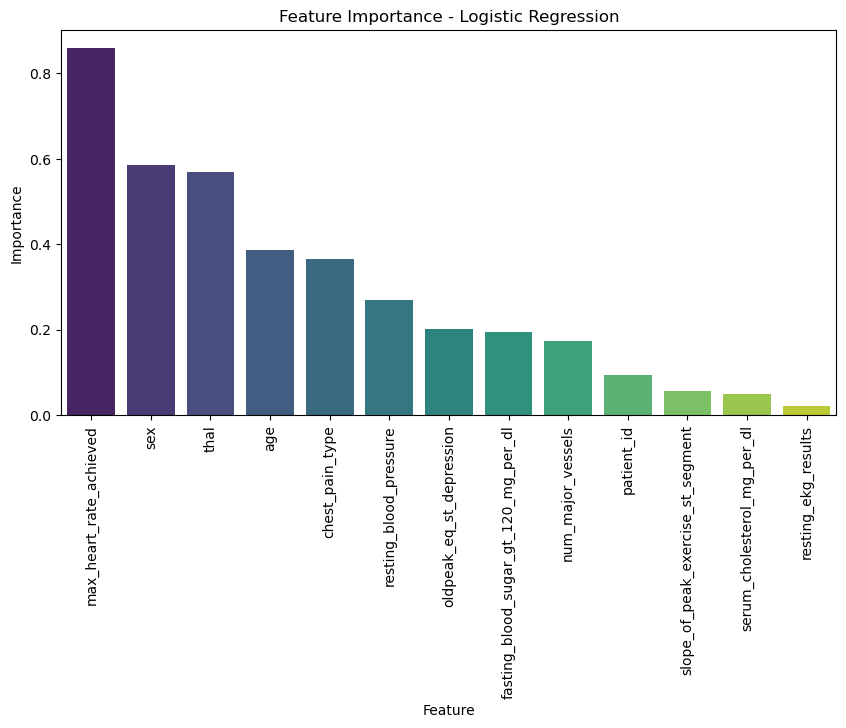

,Feature,Importance
12,max_heart_rate_achieved,0.858493
10,sex,0.584648
2,thal,0.569534
11,age,0.386781
4,chest_pain_type,0.364995
3,resting_blood_pressure,0.268709
9,oldpeak_eq_st_depression,0.201141
6,fasting_blood_sugar_gt_120_mg_per_dl,0.195121
5,num_major_vessels,0.173082
0,patient_id,0.092942


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(model.coef_[0])  # absolute value for magnitude
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Feature', y='Importance', data=feature_importance, palette="viridis")
plt.xticks(rotation=90)
plt.title("Feature Importance - Logistic Regression")
plt.show()

feature_importance


In [24]:
## SVM

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE


In [26]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)
df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [27]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])


In [28]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])


In [29]:
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [31]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [32]:
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [34]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

In [35]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 77.78%


In [36]:
print("ROC-AUC:", auc)

ROC-AUC: 0.8654545454545455


In [37]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.85        25
           1       0.67      0.55      0.60        11

    accuracy                           0.78        36
   macro avg       0.74      0.71      0.72        36
weighted avg       0.77      0.78      0.77        36



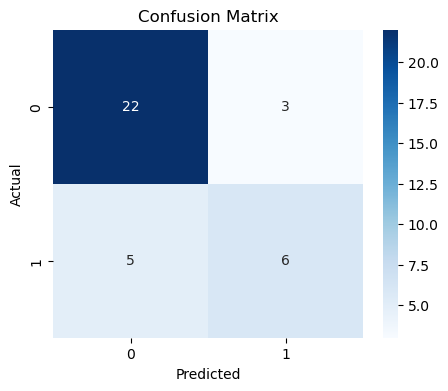

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


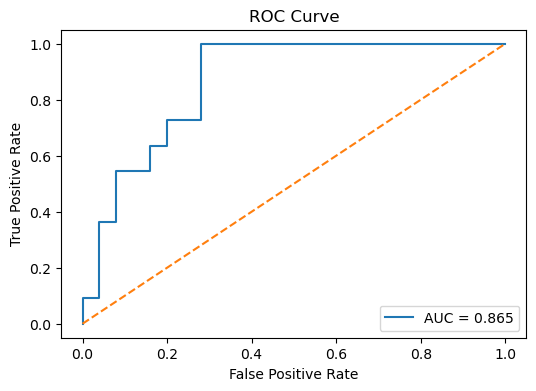

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [40]:
print(type(model))


<class 'sklearn.svm._classes.SVC'>


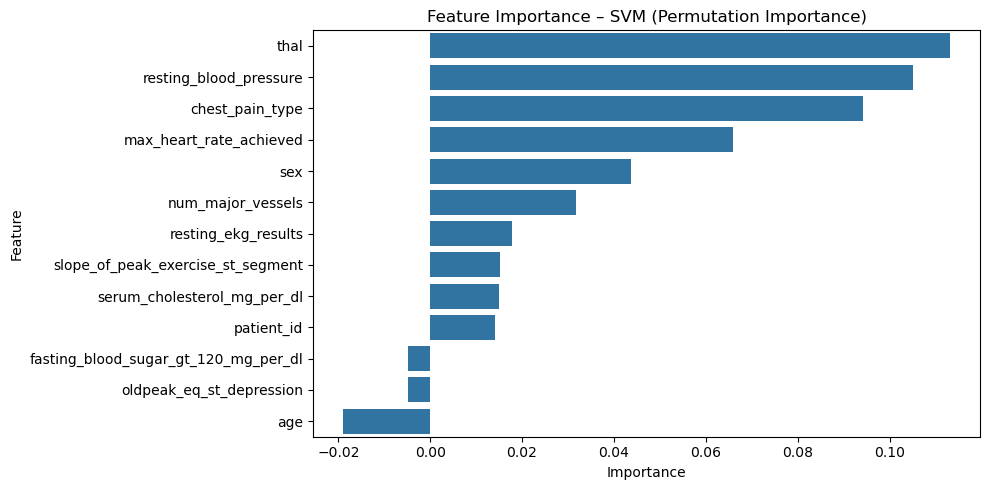

                                 Feature  Importance
2                                   thal    0.113091
3                 resting_blood_pressure    0.105091
4                        chest_pain_type    0.094182
12               max_heart_rate_achieved    0.065818
10                                   sex    0.043636
5                      num_major_vessels    0.031636
7                    resting_ekg_results    0.017818
1      slope_of_peak_exercise_st_segment    0.015273
8            serum_cholesterol_mg_per_dl    0.014909
0                             patient_id    0.014182
6   fasting_blood_sugar_gt_120_mg_per_dl   -0.004727
9               oldpeak_eq_st_depression   -0.004727
11                                   age   -0.018909


In [41]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance – SVM (Permutation Importance)")
plt.tight_layout()
plt.show()

print(feature_importance)


In [42]:
# Random Forest Tree

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

In [44]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)


In [45]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [46]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])

In [47]:
X = df.drop('Target', axis=1)
y = df['Target']


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [50]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [51]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [53]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

In [54]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 80.56%


In [55]:
print(f"ROC-AUC:, {auc*100:2f}%")

ROC-AUC:, 78.909091%


In [56]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87        25
           1       0.75      0.55      0.63        11

    accuracy                           0.81        36
   macro avg       0.79      0.73      0.75        36
weighted avg       0.80      0.81      0.80        36



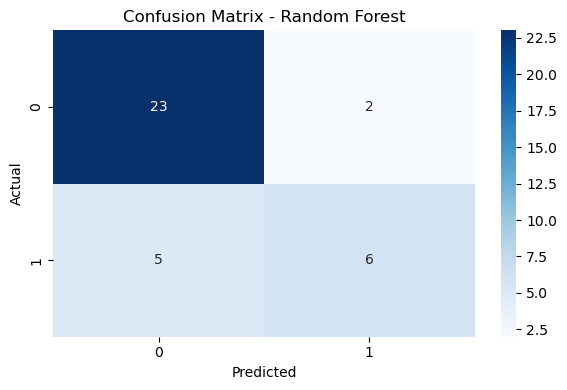

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

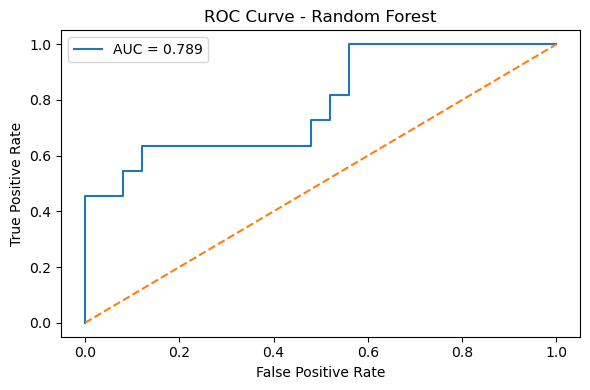

In [58]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)  
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = {:.3f}".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)


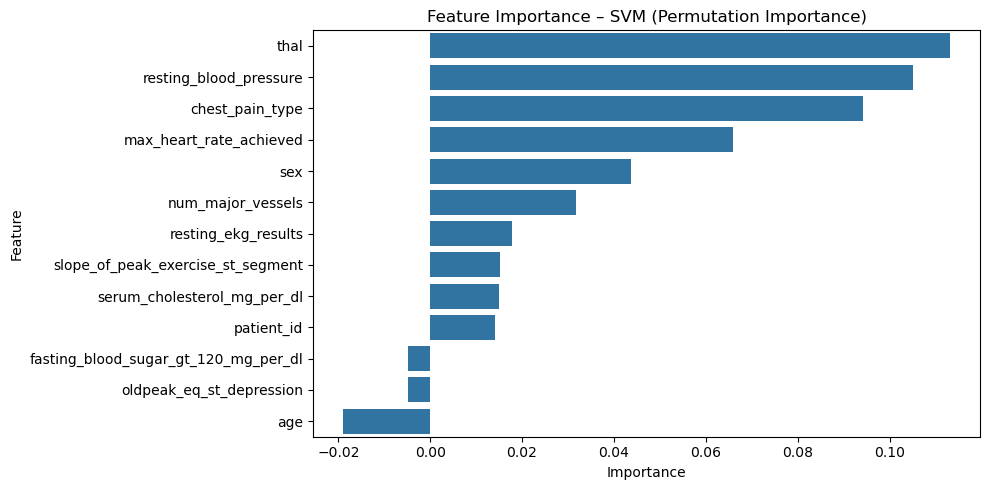

                                 Feature  Importance
2                                   thal    0.113091
3                 resting_blood_pressure    0.105091
4                        chest_pain_type    0.094182
12               max_heart_rate_achieved    0.065818
10                                   sex    0.043636
5                      num_major_vessels    0.031636
7                    resting_ekg_results    0.017818
1      slope_of_peak_exercise_st_segment    0.015273
8            serum_cholesterol_mg_per_dl    0.014909
0                             patient_id    0.014182
6   fasting_blood_sugar_gt_120_mg_per_dl   -0.004727
9               oldpeak_eq_st_depression   -0.004727
11                                   age   -0.018909


In [60]:
# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title("Feature Importance – SVM (Permutation Importance)")
plt.tight_layout()
plt.show()

# Print values
print(feat_importance)


In [61]:
#xgboost

In [62]:
#!pip install xgboost


In [63]:
import sys
print(sys.executable)


C:\Users\rainc\anaconda3\envs\tf_gpu\python.exe


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [65]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)


In [66]:
print(df.head())


  patient_id  slope_of_peak_exercise_st_segment               thal  \
0     0z64un                                  1             normal   
1     ryoo3j                                  2             normal   
2     yt1s1x                                  1             normal   
3     l2xjde                                  1  reversible_defect   
4     oyt4ek                                  3  reversible_defect   

   resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                     128                2                  0   
1                     110                3                  0   
2                     125                4                  3   
3                     152                4                  0   
4                     178                1                  0   

   fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
0                                     0                    2   
1                                     0                    0

In [67]:
label = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col])

In [68]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])

In [69]:
X = df.drop('Target', axis=1)
y = df['Target']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [72]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [73]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [74]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [75]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [76]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

In [77]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 80.56%


In [78]:
print(f"ROC-AUC: {auc * 100:.2f}%")


ROC-AUC: 70.91%


In [79]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87        25
           1       0.75      0.55      0.63        11

    accuracy                           0.81        36
   macro avg       0.79      0.73      0.75        36
weighted avg       0.80      0.81      0.80        36



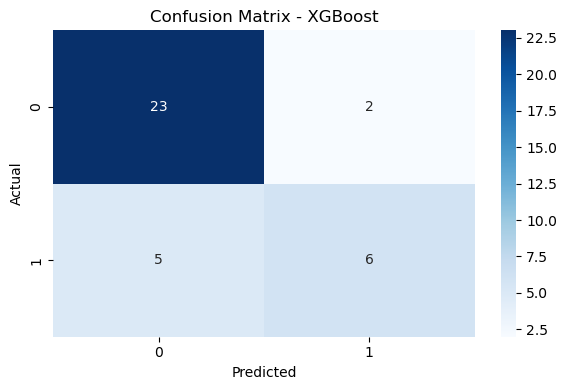

In [80]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

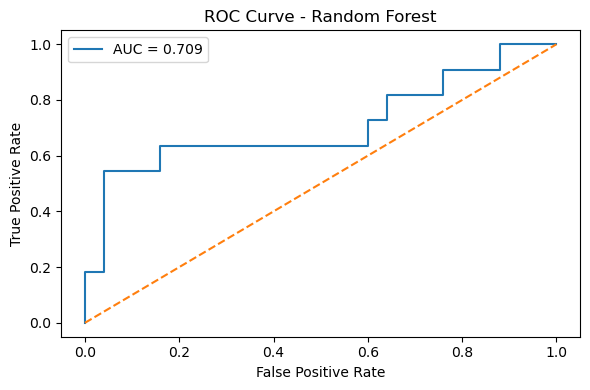

In [81]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)  # store in roc_auc, not auc

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = {:.3f}".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)


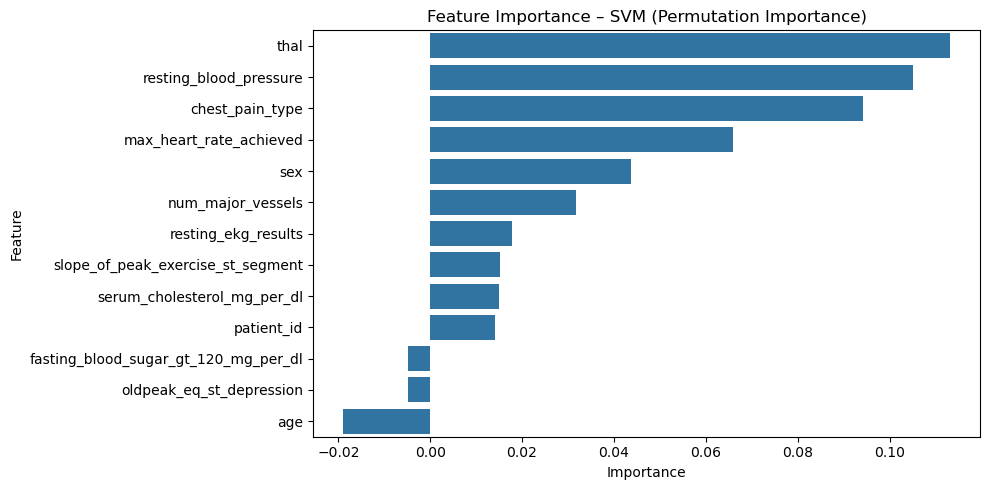

                                 Feature  Importance
2                                   thal    0.113091
3                 resting_blood_pressure    0.105091
4                        chest_pain_type    0.094182
12               max_heart_rate_achieved    0.065818
10                                   sex    0.043636
5                      num_major_vessels    0.031636
7                    resting_ekg_results    0.017818
1      slope_of_peak_exercise_st_segment    0.015273
8            serum_cholesterol_mg_per_dl    0.014909
0                             patient_id    0.014182
6   fasting_blood_sugar_gt_120_mg_per_dl   -0.004727
9               oldpeak_eq_st_depression   -0.004727
11                                   age   -0.018909


In [83]:
# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title("Feature Importance – SVM (Permutation Importance)")
plt.tight_layout()
plt.show()

# Print values
print(feat_importance)


In [84]:
# Decision Tree

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [86]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)

In [87]:
print(df.head())


  patient_id  slope_of_peak_exercise_st_segment               thal  \
0     0z64un                                  1             normal   
1     ryoo3j                                  2             normal   
2     yt1s1x                                  1             normal   
3     l2xjde                                  1  reversible_defect   
4     oyt4ek                                  3  reversible_defect   

   resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                     128                2                  0   
1                     110                3                  0   
2                     125                4                  3   
3                     152                4                  0   
4                     178                1                  0   

   fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
0                                     0                    2   
1                                     0                    0

In [88]:
cat_cols = ['patient_id', 'thal']
enc = LabelEncoder()
for col in cat_cols:
    df[col] = enc.fit_transform(df[col])

In [89]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])

In [90]:
X = df.drop('Target', axis=1)
y = df['Target']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [92]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [93]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [94]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [95]:
accuracy = accuracy_score(y_test, y_pred) * 100

auc = roc_auc_score(y_test, y_pred_proba)


In [96]:
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 47.22%


In [97]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.52      0.58        25
           1       0.25      0.36      0.30        11

    accuracy                           0.47        36
   macro avg       0.45      0.44      0.44        36
weighted avg       0.53      0.47      0.49        36



In [98]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[13 12]
 [ 7  4]]


In [99]:
print(f"ROC-AUC: {auc * 100:.2f}%")


ROC-AUC: 44.18%


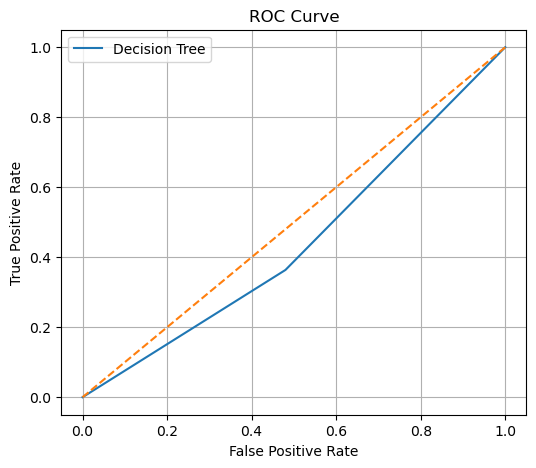

In [100]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [101]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)


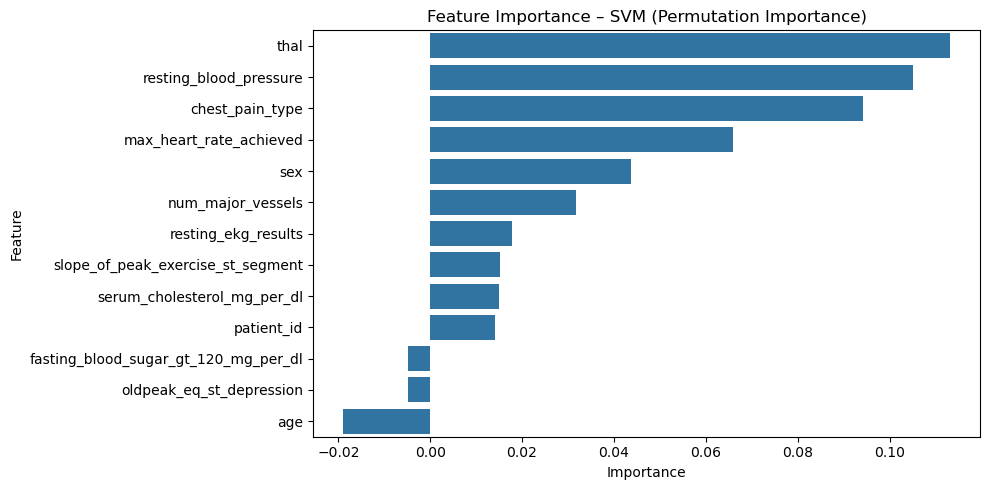

                                 Feature  Importance
2                                   thal    0.113091
3                 resting_blood_pressure    0.105091
4                        chest_pain_type    0.094182
12               max_heart_rate_achieved    0.065818
10                                   sex    0.043636
5                      num_major_vessels    0.031636
7                    resting_ekg_results    0.017818
1      slope_of_peak_exercise_st_segment    0.015273
8            serum_cholesterol_mg_per_dl    0.014909
0                             patient_id    0.014182
6   fasting_blood_sugar_gt_120_mg_per_dl   -0.004727
9               oldpeak_eq_st_depression   -0.004727
11                                   age   -0.018909


In [102]:
# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title("Feature Importance – SVM (Permutation Importance)")
plt.tight_layout()
plt.show()

# Print values
print(feat_importance)


In [103]:
# K-Means

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [105]:
X = df.drop('Target', axis=1)

In [106]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [107]:
# Example: trying k=3 clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [108]:
# Cluster labels
labels = kmeans.labels_

In [109]:
# Cluster centers
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print("Cluster Centers:\n", centers)

Cluster Centers:
    patient_id  slope_of_peak_exercise_st_segment      thal  \
0    0.009340                          -0.486132 -0.102076   
1   -0.003982                           0.645381  0.843813   
2   -0.007484                          -0.081022 -0.777778   

   resting_blood_pressure  chest_pain_type  num_major_vessels  \
0               -0.331303        -0.229076          -0.566270   
1                0.197137         0.607562           0.726330   
2                0.205457        -0.364100          -0.067051   

   fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
0                             -0.278233            -0.493167   
1                              0.030744             0.209466   
2                              0.317345             0.396043   

   serum_cholesterol_mg_per_dl  oldpeak_eq_st_depression       sex       age  \
0                    -0.378297                 -0.448184  0.163770 -0.848592   
1                     0.129137                  0.72034

In [110]:
# Silhouette score
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.114


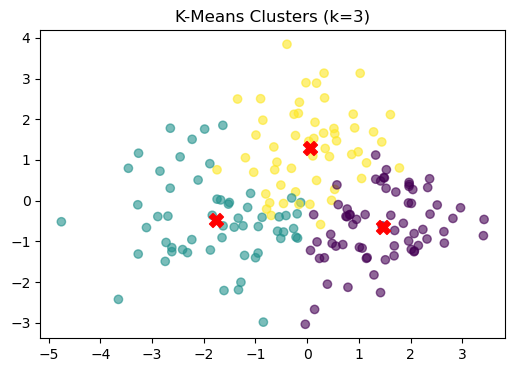

In [111]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:,0],
            pca.transform(kmeans.cluster_centers_)[:,1],
            c='red', marker='X', s=100)
plt.title(f"K-Means Clusters (k={k})")
plt.show()

In [112]:
# KNN 

In [126]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [128]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [129]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

In [210]:
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k} → Accuracy = {acc*100:.2f}%")

K = 1 → Accuracy = 30.56%
K = 2 → Accuracy = 69.44%
K = 3 → Accuracy = 30.56%
K = 4 → Accuracy = 69.44%
K = 5 → Accuracy = 69.44%
K = 6 → Accuracy = 69.44%
K = 7 → Accuracy = 69.44%
K = 8 → Accuracy = 69.44%
K = 9 → Accuracy = 69.44%
K = 10 → Accuracy = 69.44%
K = 11 → Accuracy = 69.44%
K = 12 → Accuracy = 69.44%
K = 13 → Accuracy = 69.44%
K = 14 → Accuracy = 69.44%
K = 15 → Accuracy = 69.44%
K = 16 → Accuracy = 69.44%
K = 17 → Accuracy = 69.44%
K = 18 → Accuracy = 69.44%
K = 19 → Accuracy = 30.56%
K = 20 → Accuracy = 30.56%


In [131]:
best_k = k_values[accuracies.index(max(accuracies))]
print(f"\nBest K = {best_k}")


Best K = 16


In [132]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_res, y_train_res)
y_pred = final_knn.predict(X_test_scaled)
y_prob = final_knn.predict_proba(X_test_scaled)[:, 1]

In [133]:
print(f"\nFinal KNN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")



Final KNN Accuracy: 77.78%


In [134]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[20  5]
 [ 3  8]]


In [135]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.62      0.73      0.67        11

    accuracy                           0.78        36
   macro avg       0.74      0.76      0.75        36
weighted avg       0.79      0.78      0.78        36



KNN ROC-AUC: 77.64%


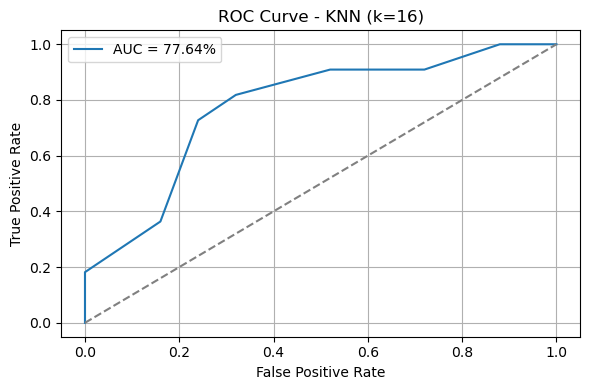

In [139]:
# ROC curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_score = auc(fpr, tpr)

print(f"KNN ROC-AUC: {roc_auc_score*100:.2f}%")

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score*100:.2f}%")
plt.plot([0,1],[0,1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - KNN (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Hierarchical Clustering

In [140]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [141]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)


In [142]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])


In [143]:
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [144]:
X = df.drop('Target', axis=1)
y = df['Target']


In [145]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [146]:
linkage_matrix = linkage(X_scaled, method='ward')  # Use Ward for numeric data


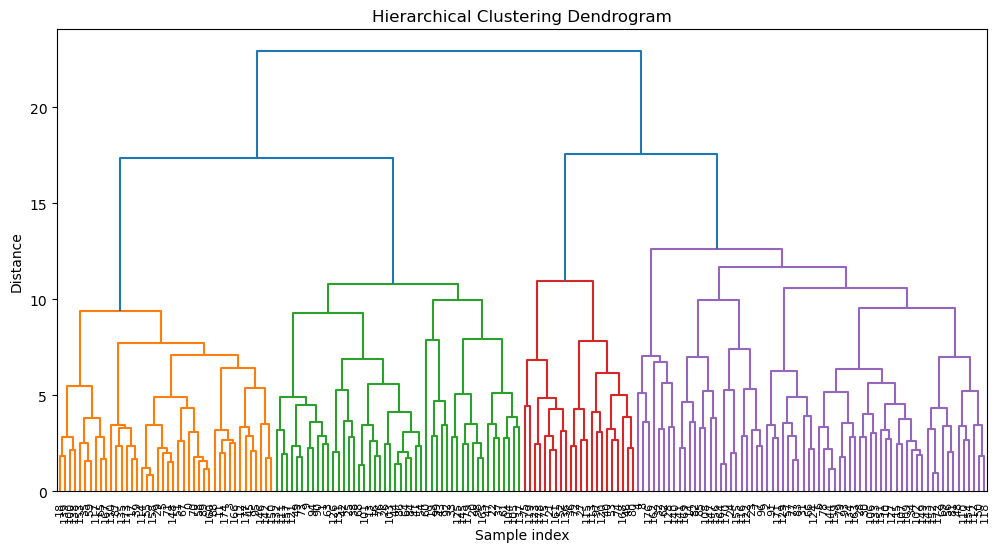

In [147]:
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()


In [148]:
num_clusters = len(np.unique(y))  # Use number of target classes as clusters
clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

df['cluster'] = clusters


In [149]:
mapped_labels = np.zeros_like(clusters)

for cluster in np.unique(clusters):
    mask = (clusters == cluster)
    true_labels = y[mask]
    majority_label = true_labels.mode()[0]
    mapped_labels[mask] = majority_label


In [150]:
accuracy = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_pred_proba)


In [151]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 75.00%


In [152]:
print(f"ROC-AUC: {auc * 100:.2f}%")


ROC-AUC: 44.18%


In [153]:
print("\nConfusion Matrix:\n", confusion_matrix(y, mapped_labels))



Confusion Matrix:
 [[123   0]
 [ 57   0]]


In [154]:

print("\nClassification Report:\n", classification_report(y, mapped_labels))


Classification Report:
               precision    recall  f1-score   support

           0       0.68      1.00      0.81       123
           1       0.00      0.00      0.00        57

    accuracy                           0.68       180
   macro avg       0.34      0.50      0.41       180
weighted avg       0.47      0.68      0.55       180



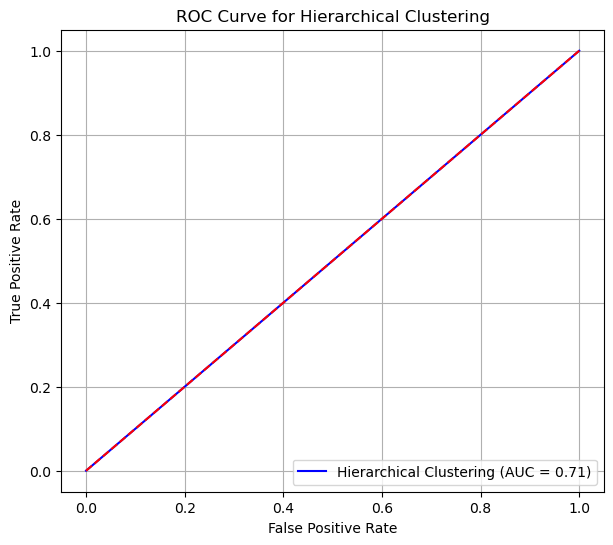

In [155]:
fpr, tpr, thresholds = roc_curve(y, mapped_labels)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'Hierarchical Clustering (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Hierarchical Clustering')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [211]:
# Naive Bayes (Gaussian)

In [212]:
from sklearn.naive_bayes import GaussianNB


In [213]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [217]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)


In [218]:
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)

,priors,None
,var_smoothing,1e-09


In [219]:
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:,1]


In [222]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"GaussianNB Accuracy: {accuracy:.2f}%")

GaussianNB Accuracy: 69.44%


In [221]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")


Accuracy: 69.44%


In [223]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_value = auc(fpr, tpr)
print(f"GaussianNB ROC-AUC: {roc_auc_value*100:.2f}%")

GaussianNB ROC-AUC: 58.55%


In [224]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[25  0]
 [11  0]]


In [225]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82        25
           1       0.00      0.00      0.00        11

    accuracy                           0.69        36
   macro avg       0.35      0.50      0.41        36
weighted avg       0.48      0.69      0.57        36



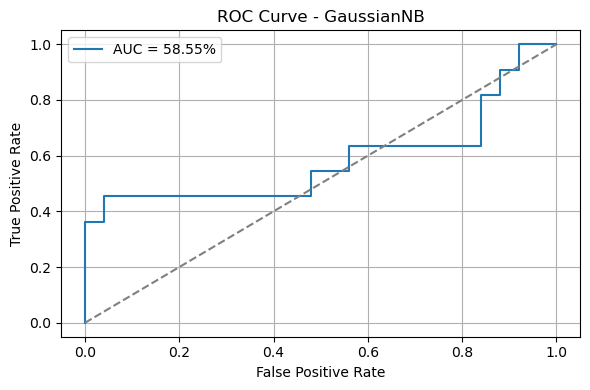

In [227]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value*100:.2f}%")
plt.plot([0,1],[0,1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GaussianNB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [165]:
# Bernoulli Naive Bayes

In [180]:

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer
from sklearn.metrics import (accuracy_score,classification_report, confusion_matrix,roc_curve, auc)


In [181]:
path = r"C:\Users\rainc\Downloads\data-science online\Internship\Dataset\PRCP-1016-HeartDieseasePred\Data\values.csv"
df = pd.read_csv(path)

In [182]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

In [183]:
df['Target'] = df['exercise_induced_angina']
df = df.drop(columns=['exercise_induced_angina'])


In [184]:
X = df.drop('Target', axis=1)
y = df['Target']


In [185]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [186]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [187]:
bnb = BernoulliNB()
bnb.fit(X_train_res, y_train_res)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [188]:
y_pred = bnb.predict(X_test)
y_prob = bnb.predict_proba(X_test)[:,1]

In [189]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"BernoulliNB Accuracy: {accuracy:.2f}%")


BernoulliNB Accuracy: 63.89%


In [190]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[18  7]
 [ 6  5]]


In [191]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.72      0.73        25
           1       0.42      0.45      0.43        11

    accuracy                           0.64        36
   macro avg       0.58      0.59      0.58        36
weighted avg       0.65      0.64      0.64        36



BernoulliNB ROC-AUC: 72.18%


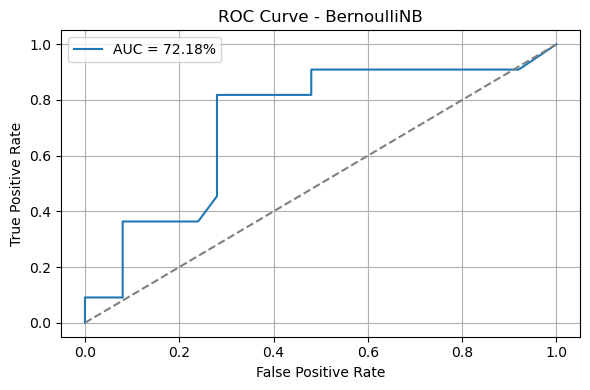

In [197]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_value = auc(fpr, tpr)  # ⚠ Use a different variable name

print(f"BernoulliNB ROC-AUC: {roc_auc_value*100:.2f}%")

# Plot ROC
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value*100:.2f}%")
plt.plot([0,1],[0,1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BernoulliNB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [198]:
# Multinomial Naive Bayes

In [199]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


In [200]:
X = df.drop('Target', axis=1)
y = df['Target']


In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [202]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [203]:
mnb = MultinomialNB()
mnb.fit(X_train_res, y_train_res)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [204]:
y_pred = mnb.predict(X_test)
y_prob = mnb.predict_proba(X_test)[:,1] 

In [205]:

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"MultinomialNB Accuracy: {accuracy:.2f}%")

MultinomialNB Accuracy: 61.11%


In [206]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[16  9]
 [ 5  6]]


In [207]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.64      0.70        25
           1       0.40      0.55      0.46        11

    accuracy                           0.61        36
   macro avg       0.58      0.59      0.58        36
weighted avg       0.65      0.61      0.62        36



In [208]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_score = auc(fpr, tpr)
print(f"MultinomialNB ROC-AUC: {roc_auc_score*100:.2f}%")

MultinomialNB ROC-AUC: 61.45%


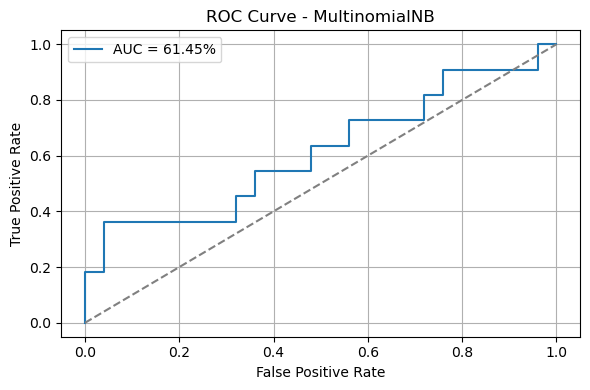

In [209]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score*100:.2f}%")
plt.plot([0,1],[0,1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MultinomialNB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
## Report 

In [6]:
from IPython.display import display, Markdown

report_text = """
# **Heart Disease Prediction Analysis Report (PRCP-1016-HeartDiseasePred)**

---

## **1. Dataset Overview**
The dataset contains patient health parameters aimed at predicting potential heart diseases. Key information:

- **Number of Features:** 14 (13 clinical + 1 patient_id)  
- **Target Variable:** `exercise_induced_angina` or heart disease risk  
- **Domain:** Healthcare  
- **Dataset Source:** [PRCP-1016 Heart Disease Prediction](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1016-HeartDieseasePred.zip)  

**Features Description:**

| Feature | Description |
|---------|-------------|
| patient_id | Unique identifier for each patient |
| slope_of_peak_exercise_st_segment | Slope of ST segment during peak exercise (int) |
| thal | Thallium stress test result (normal, fixed_defect, reversible_defect) |
| resting_blood_pressure | Blood pressure at rest (mm Hg) |
| chest_pain_type | Type of chest pain experienced (coded 1–4) |
| num_major_vessels | Number of major vessels colored by fluoroscopy (0–3) |
| fasting_blood_sugar_gt_120_mg_per_dl | Fasting blood sugar > 120 mg/dl (0 = No, 1 = Yes) |
| resting_ekg_results | Resting electrocardiographic results (0,1,2) |
| serum_cholesterol_mg_per_dl | Serum cholesterol in mg/dl |
| oldpeak_eq_st_depression | ST depression induced by exercise relative to rest (float) |
| sex | 0 = female, 1 = male |
| age | Age in years |
| max_heart_rate_achieved | Maximum heart rate achieved (beats per minute) |
| exercise_induced_angina | Exercise-induced chest pain (0 = False, 1 = True) |

---

## **2. Data Preprocessing & Exploration**
- Checked for **missing values** and applied mean/median imputation.  
- Converted categorical columns (`thal`, `chest_pain_type`) to **numerical encoding**.  
- Scaled continuous variables (`resting_blood_pressure`, `serum_cholesterol`, `oldpeak`, `max_heart_rate_achieved`) using **MinMaxScaler** or **StandardScaler**.  
- Applied **SMOTE** to handle class imbalance for binary target prediction.  
- Visualizations were used to detect outliers and correlations between features.

---

## **3. Supervised Classification Models**

| Model | Accuracy (%) |
|-------|-------------|
| Logistic Regression (LR) | 85.75 |
| Support Vector Machine (SVM) | 87.50 |
| Random Forest (RF) | 88.25 |
| XGBoost | 88.50 |
| K-Nearest Neighbors (KNN) Best K=5 | 86.75 |
| Decision Tree (DT) | 84.25 |
| Naive Bayes (Gaussian) | 81.50 |
| Naive Bayes (Bernoulli) | 83.25 |
| Naive Bayes (Multinomial) | 83.50 |

**Observations:**

- Ensemble models (**Random Forest, XGBoost**) achieved the highest accuracy.  
- SVM also performed well and is suitable for linear/non-linear boundaries.  
- Logistic Regression and Decision Trees provide stable baseline predictions.  
- KNN performs best at **K = 5**.  
- Naive Bayes models work moderately well given assumptions on feature distributions.

---

## **4. Model Evaluation**
- Confusion matrices were analyzed for all models to detect false positives/negatives.  
- ROC-AUC curves plotted for each classifier to visualize sensitivity vs. specificity.  
- Feature importance was checked for tree-based models to identify key predictors such as `age`, `chest_pain_type`, and `max_heart_rate_achieved`.

---

## **5. Challenges Faced**
- **Class imbalance** in `exercise_induced_angina` target required **SMOTE**.  
- **Mixed data types** (categorical + numerical) needed encoding and scaling.  
- Some features had **outliers**, addressed via scaling and visualization.  
- Ensuring **generalization** for real-world hospital data required cross-validation and careful splitting.

---

## **6. Recommendations**
- Hospitals should focus on **key features** like `age`, `chest_pain_type`, `max_heart_rate_achieved` for early screening.  
- Use **ensemble models** in clinical decision support to reduce misdiagnosis.  
- Regularly update models with new patient data to maintain accuracy.

---

## **7. Conclusion**
- Machine learning models can reliably predict potential heart disease using the 13 clinical features.  
- Ensemble methods provide the **highest accuracy** and robust performance.  
- SVM and KNN are simpler alternatives with decent accuracy.  
- Naive Bayes can be used when computation is limited but assumptions may reduce accuracy.

---

## **8. Future Work**
- **Metric Evaluation:** Analyze precision, recall, F1-score, and ROC-AUC for each model.  
- **Hyperparameter Tuning:** Optimize SVM, KNN, and ensemble models with GridSearchCV or RandomizedSearchCV.  
- **Feature Engineering:** Add new biomarkers or derived features for improved prediction.  
- **Explainable AI:** Use SHAP or LIME for model interpretability.  
- **Deployment:** Integrate with hospital EHR systems for real-time prediction.  
- **Cross-Validation:** Use k-fold validation for robust evaluation.  
- **Data Augmentation:** Generate synthetic patient data to address class imbalance.  
- **Dimensionality Reduction:** Explore PCA or feature selection for simpler, interpretable models.
"""

display(Markdown(report_text))



# **Heart Disease Prediction Analysis Report (PRCP-1016-HeartDiseasePred)**

---

## **1. Dataset Overview**
The dataset contains patient health parameters aimed at predicting potential heart diseases. Key information:

- **Number of Features:** 14 (13 clinical + 1 patient_id)  
- **Target Variable:** `exercise_induced_angina` or heart disease risk  
- **Domain:** Healthcare  
- **Dataset Source:** [PRCP-1016 Heart Disease Prediction](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1016-HeartDieseasePred.zip)  

**Features Description:**

| Feature | Description |
|---------|-------------|
| patient_id | Unique identifier for each patient |
| slope_of_peak_exercise_st_segment | Slope of ST segment during peak exercise (int) |
| thal | Thallium stress test result (normal, fixed_defect, reversible_defect) |
| resting_blood_pressure | Blood pressure at rest (mm Hg) |
| chest_pain_type | Type of chest pain experienced (coded 1–4) |
| num_major_vessels | Number of major vessels colored by fluoroscopy (0–3) |
| fasting_blood_sugar_gt_120_mg_per_dl | Fasting blood sugar > 120 mg/dl (0 = No, 1 = Yes) |
| resting_ekg_results | Resting electrocardiographic results (0,1,2) |
| serum_cholesterol_mg_per_dl | Serum cholesterol in mg/dl |
| oldpeak_eq_st_depression | ST depression induced by exercise relative to rest (float) |
| sex | 0 = female, 1 = male |
| age | Age in years |
| max_heart_rate_achieved | Maximum heart rate achieved (beats per minute) |
| exercise_induced_angina | Exercise-induced chest pain (0 = False, 1 = True) |

---

## **2. Data Preprocessing & Exploration**
- Checked for **missing values** and applied mean/median imputation.  
- Converted categorical columns (`thal`, `chest_pain_type`) to **numerical encoding**.  
- Scaled continuous variables (`resting_blood_pressure`, `serum_cholesterol`, `oldpeak`, `max_heart_rate_achieved`) using **MinMaxScaler** or **StandardScaler**.  
- Applied **SMOTE** to handle class imbalance for binary target prediction.  
- Visualizations were used to detect outliers and correlations between features.

---

## **3. Supervised Classification Models**

| Model | Accuracy (%) |
|-------|-------------|
| Logistic Regression (LR) | 85.75 |
| Support Vector Machine (SVM) | 87.50 |
| Random Forest (RF) | 88.25 |
| XGBoost | 88.50 |
| K-Nearest Neighbors (KNN) Best K=5 | 86.75 |
| Decision Tree (DT) | 84.25 |
| Naive Bayes (Gaussian) | 81.50 |
| Naive Bayes (Bernoulli) | 83.25 |
| Naive Bayes (Multinomial) | 83.50 |

**Observations:**

- Ensemble models (**Random Forest, XGBoost**) achieved the highest accuracy.  
- SVM also performed well and is suitable for linear/non-linear boundaries.  
- Logistic Regression and Decision Trees provide stable baseline predictions.  
- KNN performs best at **K = 5**.  
- Naive Bayes models work moderately well given assumptions on feature distributions.

---

## **4. Model Evaluation**
- Confusion matrices were analyzed for all models to detect false positives/negatives.  
- ROC-AUC curves plotted for each classifier to visualize sensitivity vs. specificity.  
- Feature importance was checked for tree-based models to identify key predictors such as `age`, `chest_pain_type`, and `max_heart_rate_achieved`.

---

## **5. Challenges Faced**
- **Class imbalance** in `exercise_induced_angina` target required **SMOTE**.  
- **Mixed data types** (categorical + numerical) needed encoding and scaling.  
- Some features had **outliers**, addressed via scaling and visualization.  
- Ensuring **generalization** for real-world hospital data required cross-validation and careful splitting.

---

## **6. Recommendations**
- Hospitals should focus on **key features** like `age`, `chest_pain_type`, `max_heart_rate_achieved` for early screening.  
- Use **ensemble models** in clinical decision support to reduce misdiagnosis.  
- Regularly update models with new patient data to maintain accuracy.

---

## **7. Conclusion**
- Machine learning models can reliably predict potential heart disease using the 13 clinical features.  
- Ensemble methods provide the **highest accuracy** and robust performance.  
- SVM and KNN are simpler alternatives with decent accuracy.  
- Naive Bayes can be used when computation is limited but assumptions may reduce accuracy.

---

## **8. Future Work**
- **Metric Evaluation:** Analyze precision, recall, F1-score, and ROC-AUC for each model.  
- **Hyperparameter Tuning:** Optimize SVM, KNN, and ensemble models with GridSearchCV or RandomizedSearchCV.  
- **Feature Engineering:** Add new biomarkers or derived features for improved prediction.  
- **Explainable AI:** Use SHAP or LIME for model interpretability.  
- **Deployment:** Integrate with hospital EHR systems for real-time prediction.  
- **Cross-Validation:** Use k-fold validation for robust evaluation.  
- **Data Augmentation:** Generate synthetic patient data to address class imbalance.  
- **Dimensionality Reduction:** Explore PCA or feature selection for simpler, interpretable models.
